Colab de referência: https://colab.research.google.com/drive/1s0wK-XDQOdUubutjqhJVQL-6q6jKAfy9

Consideração sobre o uso do parâmetro *inplace=True*:
* *inplace=True* está em **desaprovação no Pandas 3.0**, ou seja, ainda existe compatibilidade, mas não deve ser mais usado, pois será removido no futuro;
* O recomendável é não usar o inplace=True e reassinalar o DataFrame modificado a mesma variável.
* Objetivo de usar o padrão de realocação de DataFrame: simplicar a operação do DataFrame, reduzir erros potenciais, e melhorar a desempenho de execução;

Limpeza dos dados
* Valores ausentes;
* Valores duplicados;
* *Outliers*;
* Formatação.

In [4]:
import pandas as pd

url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

titanic = pd.read_csv(url)

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Tratamento de valores ausentes

In [5]:
# visualizar a quantidade de valores nulos por característica
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

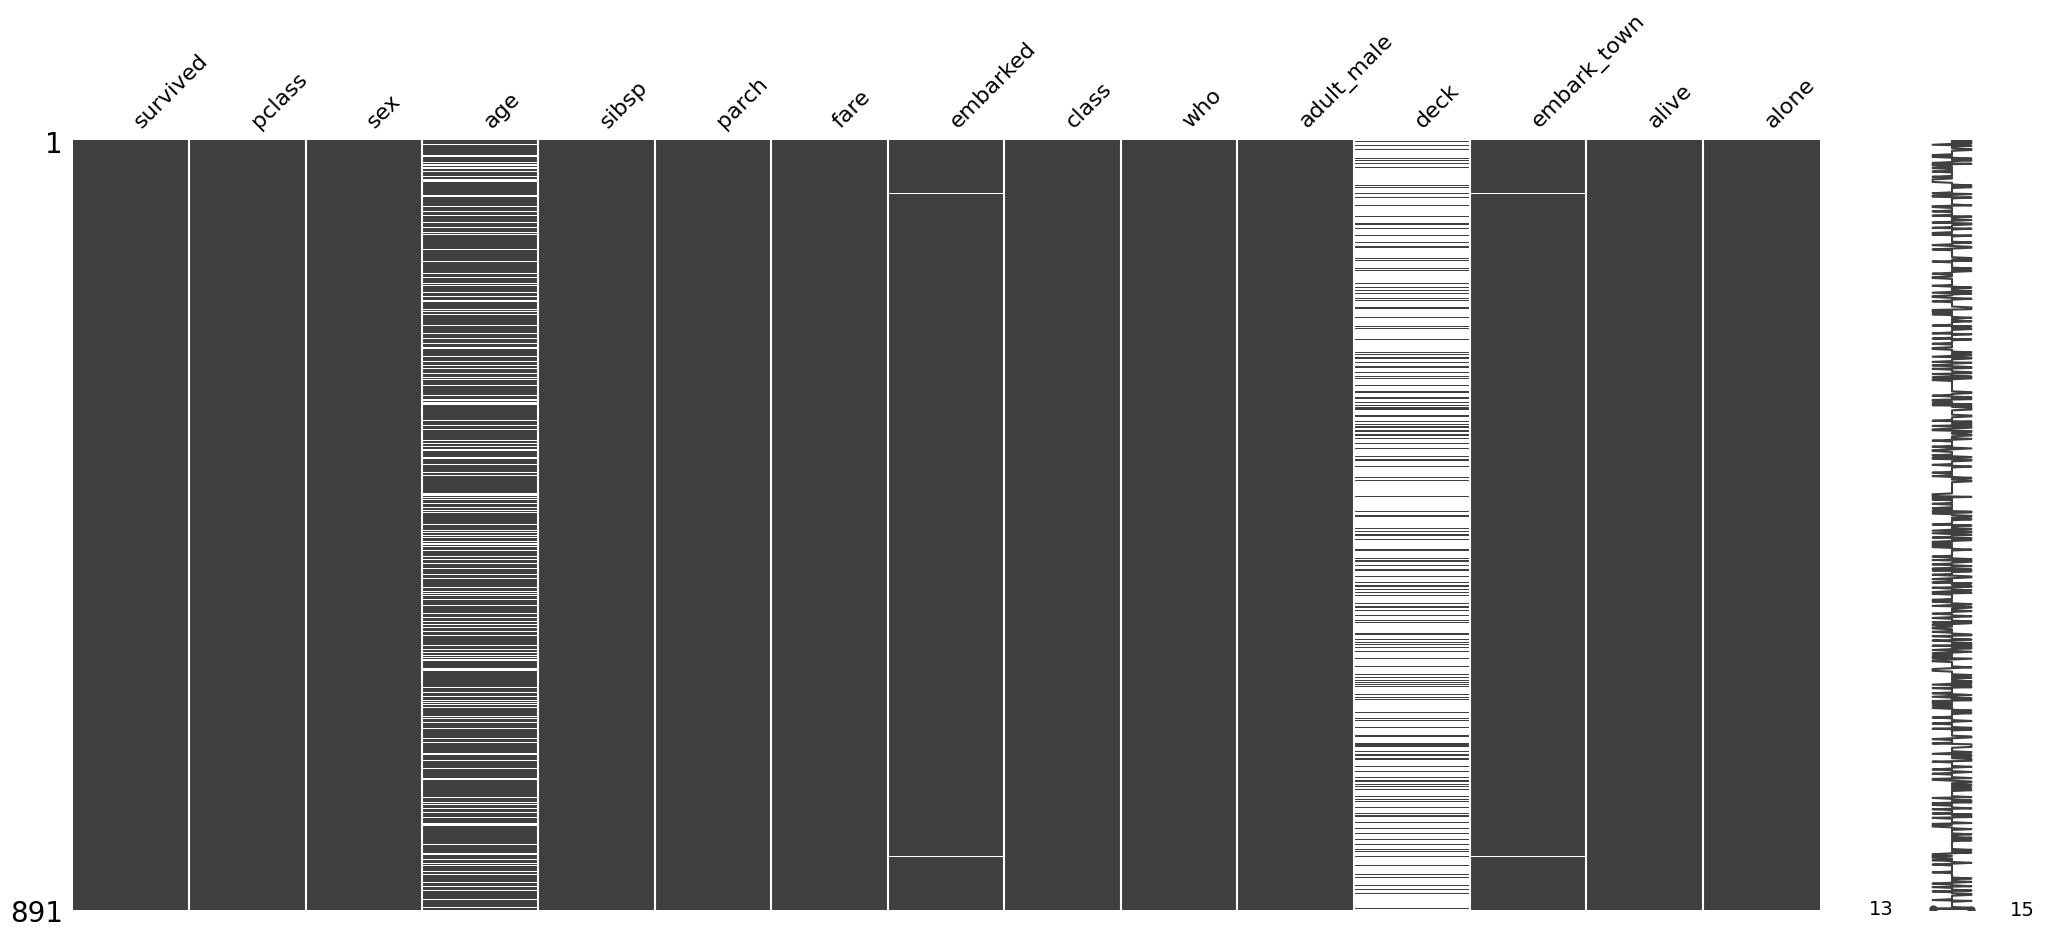

In [3]:
# visualizar valores ausentes de forma gráfica
# pip install missingno
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(titanic)
plt.show()

In [7]:
# preencher valores nulos - função fillna não necessita de inplace=True
titanic['age'].fillna(titanic['age'].mean())

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: age, Length: 891, dtype: float64

In [8]:
# como corrigir o problema do inplace
titanic['age'] = titanic['age'].fillna(titanic['age'].mean())
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [35]:
titanic.shape

(891, 15)

In [43]:
# encontrar duplicados
titanic.loc[titanic.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone


In [9]:
# remover duplicados
titanic.drop_duplicates(inplace=True)
titanic.shape[0]

784

Tratamento de *outliers*